<a href="https://colab.research.google.com/github/Ravravan/pytorch/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORT MNIST

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import  make_grid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
%matplotlib inline




In [31]:
# converts MNIST images into a tensor of 4-D
transform = transforms.ToTensor()

In [32]:
#train data
train_data = datasets.MNIST(root='/cnn_data', train=True, download = True, transform=transform)

In [33]:
#test data
test_data = datasets.MNIST(root='/cnn_data', train=False, download = True, transform=transform)

In [34]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [35]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

#Convolutional and pooling layers

In [36]:
#create a small batch size for images..
train_loader= DataLoader(train_data, batch_size=10, shuffle= True   )
test_loader= DataLoader(test_data, batch_size=10, shuffle= False  )

In [37]:
#define CNN model
conv1 = nn.Conv2d(1, 6, 3, 1)
conv2 = nn.Conv2d(6, 16, 3, 1)

In [38]:
#grab 1 MNIST record/image
for i, (x_train, y_train) in enumerate(train_data):
  break

In [39]:
x_train

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [40]:
x_train.shape


torch.Size([1, 28, 28])

In [41]:
x = x_train.view([1,1,28,28])

In [42]:
#perform our 1st convolution
x = F.relu(conv1(x)) # rectified linear unit for our activation function..

In [43]:
x

tensor([[[[0.3272, 0.3272, 0.3272,  ..., 0.3272, 0.3272, 0.3272],
          [0.3272, 0.3272, 0.3272,  ..., 0.3272, 0.3272, 0.3272],
          [0.3272, 0.3272, 0.3272,  ..., 0.3272, 0.3272, 0.3272],
          ...,
          [0.3272, 0.3272, 0.3136,  ..., 0.3272, 0.3272, 0.3272],
          [0.3272, 0.3272, 0.1525,  ..., 0.3272, 0.3272, 0.3272],
          [0.3272, 0.3272, 0.3272,  ..., 0.3272, 0.3272, 0.3272]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0

In [44]:
x.shape # lose  of 2pixels due to the padding..

torch.Size([1, 6, 26, 26])

In [45]:
 # pooling layer
x= F.max_pool2d(x, 2, 2)

In [46]:
x.shape

torch.Size([1, 6, 13, 13])

In [47]:
#do our second convolutional layer
x= F.relu(conv2(x))

In [48]:
x

tensor([[[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 3.2903e-02, 0.0000e+00,  ..., 1.1467e-02,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 4.5326e-02, 3.6872e-02,  ..., 5.5794e-02,
           6.2530e-02, 4.1875e-02],
          ...,
          [0.0000e+00, 1.3360e-02, 6.1424e-03,  ..., 5.9499e-02,
           0.0000e+00, 0.0000e+00],
          [2.0926e-03, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [5.4498e-02, 3.7192e-02, 5.7824e-02,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]],

         [[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000

In [49]:
x.shape # same here lose 2 pixels beacuse of the padding.We did not set any padding..

torch.Size([1, 16, 11, 11])

In [50]:
#pooling layer
x=F.max_pool2d(x,2,2)

In [51]:
x.shape

torch.Size([1, 16, 5, 5])

#MODEL

In [52]:
#model class
class convolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1,6,3,1)
    self.conv2 = nn.Conv2d(6,16,3,1)

    #full connected layer
    self.fc1 =nn.Linear(5*5*16, 120)
    self.fc2 =nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x= F.relu(self.conv1(x))
    x=F.max_pool2d(x,2,2)
    #second pass
    x= F.relu(self.conv2(x))
    x=F.max_pool2d(x,2,2)

    #re-view to flatten it out
    x = x.view(-1, 16*5*5)


    #fully connected layer

    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x=self.fc3(x)

    return F.log_softmax(x, dim=1)

In [53]:
#create an instance of our model
torch.manual_seed(41)
model = convolutionalNetwork()
model

convolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [76]:
#loss function optimizer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#TRAIN AND TEST

In [55]:
import time
start_time = time.time()

#create variable to tracks things
epochs = 5
train_losses =[]
test_losses = []
train_correct = []
test_correct = []

#foor loop of epochs

for i in  range(epochs):
  trn_corr = 0
  tst_corr = 0


  #train

  for b,(x_train, y_train ) in enumerate(train_loader):
    b+=1
    y_pred  = model(x_train)
    loss = criterion(y_pred, y_train)

    predicted = torch.max(y_pred.data, 1)[1]
    batch_corr = (predicted == y_train).sum()
    trn_corr += batch_corr

#update our parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    #print out some results


    if b%600 ==0:
      print(f'Epoch:{i}  Batch:{b} Loss:{loss.item()}')

    train_losses.append(loss)
    train_correct.append(trn_corr)



 #test

  with torch.no_grad():
   for b,(x_test, y_test) in enumerate(test_loader):
    y_val = model(x_test)
    predited = torch.max(y_val.data, 1)[1]
    tst_corr += (predicted == y_test).sum()
    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)



current_time = time.time()
total = current_time - start_time
print(f'Training took: {total/60} min!')


Epoch:0  Batch:600 Loss:0.16236107051372528
Epoch:0  Batch:1200 Loss:0.15510495007038116
Epoch:0  Batch:1800 Loss:0.4651116728782654
Epoch:0  Batch:2400 Loss:0.17726822197437286
Epoch:0  Batch:3000 Loss:0.007429888937622309
Epoch:0  Batch:3600 Loss:0.37731707096099854
Epoch:0  Batch:4200 Loss:0.004938055761158466
Epoch:0  Batch:4800 Loss:0.0015040982980281115
Epoch:0  Batch:5400 Loss:0.06845302879810333
Epoch:0  Batch:6000 Loss:0.0004587689763866365
Epoch:1  Batch:600 Loss:0.002925408538430929
Epoch:1  Batch:1200 Loss:0.2792360186576843
Epoch:1  Batch:1800 Loss:0.0018853390356525779
Epoch:1  Batch:2400 Loss:0.0030733426101505756
Epoch:1  Batch:3000 Loss:0.024190708994865417
Epoch:1  Batch:3600 Loss:0.5062173008918762
Epoch:1  Batch:4200 Loss:0.02014169655740261
Epoch:1  Batch:4800 Loss:0.001421573688276112
Epoch:1  Batch:5400 Loss:0.0006034405087120831
Epoch:1  Batch:6000 Loss:0.1528162956237793
Epoch:2  Batch:600 Loss:0.07298740744590759
Epoch:2  Batch:1200 Loss:0.002216457389295101
E

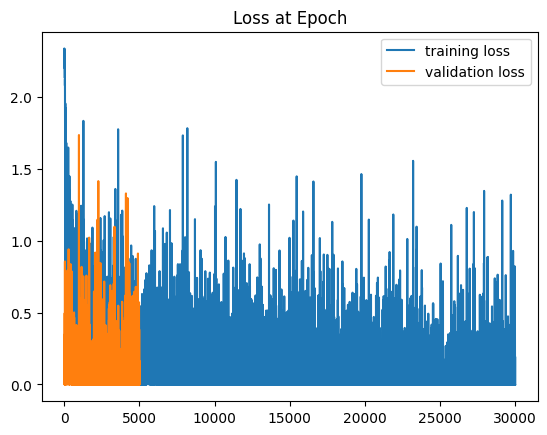

In [71]:
plt.plot(train_losses, label='training loss')
plt.plot(test_losses, label='validation loss')
plt.title('Loss at Epoch')
plt.legend()

In [81]:
test_load_everything = DataLoader(test_data, batch_size=10000, shuffle=False)

In [82]:
with torch.no_grad():
  correct = 0
  for x_test, y_test in test_load_everything:
    y_val = model(x_test)
    predicted = torch.max(y_val, 1)[1]
    correct += (predicted == y_test).sum()


In [87]:
correct.item()/len(test_data)*100

98.24000000000001